import pandas as pd

studentsdf = pd.read_csv('Dataset/AWS_results.csv')
answersdf = pd.read_csv('Dataset/AWS_answers.csv')
studentsdf

In [95]:
import pandas as pd
studentsdf = pd.read_csv('Dataset/AWS_results.csv')
studentsdf = studentsdf.reset_index()
studentsdf

,index,IDs,1,2,3,4,5,6,7,8,...,21,22,23,24,25,26,27,Total,Percent,Level
0,0,anj,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,7,25.925926,Beginner
1,1,ala,1,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,8,29.629630,Beginner
2,2,ndr,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,14,51.851852,Beginner
3,3,nav,1,0,1,0,1,1,1,0,...,1,0,0,0,0,0,0,10,40.740741,Beginner
4,4,van,1,1,1,1,0,0,1,1,...,1,0,0,0,1,0,0,14,51.851852,Beginner
5,5,uma,0,1,1,0,1,1,0,1,...,0,0,0,0,0,0,0,10,37.037037,Beginner
6,6,ngh,1,0,1,1,0,1,1,0,...,1,0,1,1,0,1,1,20,74.074074,Advanced
7,7,nat,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,6,22.222222,Beginner
8,8,thy,1,0,0,1,0,1,1,0,...,0,0,0,0,0,0,0,11,40.740741,Beginner
9,9,sk,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,17,62.962963,Intermediate


In [96]:
studentsdf.columns

Index(['index', 'IDs', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11',
       '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23',
       '24', '25', '26', '27', 'Total', 'Percent', 'Level'],
      dtype='object')

In [97]:
percentCounts = studentsdf.groupby('Percent')['Total'].count()
percentCounts

Percent
14.814815    1
22.222222    2
25.925926    2
29.629630    2
33.333333    2
37.037037    5
40.740741    3
44.444444    3
48.148148    1
51.851852    3
55.555556    4
59.259259    5
62.962963    4
66.666667    2
70.370370    4
74.074074    2
77.777778    4
81.481481    1
88.888889    4
92.592593    5
96.296296    1
Name: Total, dtype: int64

In [121]:
bins = [0,40,50,60,70,80,90,100]
labels = ['<40','<50','<60','<70','<80','<90','<100']

studentsdf['group'] = pd.cut(studentsdf['Percent'], bins = bins, labels = labels, right = False)

values = studentsdf.value_counts('group').sort_index(key=lambda x: x.str.replace('<', '').astype(int))
values

group
<40     14
<50      7
<60     12
<70      6
<80     10
<90      5
<100     6
Name: count, dtype: int64

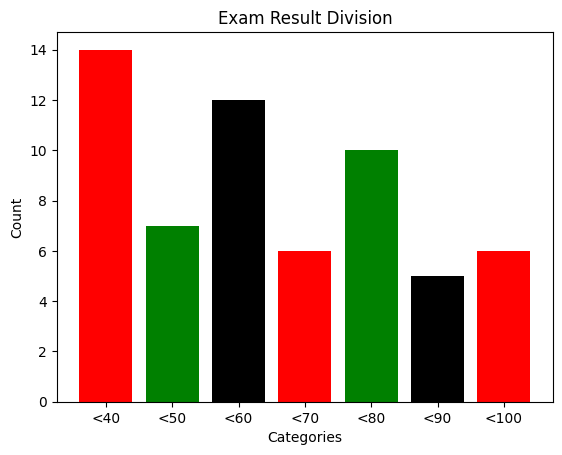

In [122]:
import matplotlib.pyplot as plt

plt.bar(labels, values, color = ['red', 'g', 'black'], width = 0.8)

plt.xlabel('Categories')
plt.ylabel('Count')
plt.title('Exam Result Division')

plt.show()

In [123]:
newdf = studentsdf[['IDs','Total','Percent']]
newdf

,IDs,Total,Percent
0,anj,7,25.925926
1,ala,8,29.629630
2,ndr,14,51.851852
3,nav,10,40.740741
4,van,14,51.851852
5,uma,10,37.037037
6,ngh,20,74.074074
7,nat,6,22.222222
8,thy,11,40.740741
9,sk,17,62.962963


In [124]:
studentsdf['Level'] = newdf['Percent'].apply( lambda x : 'Advanced' if x >= 70 else 'Beginner')

In [125]:
studentsdf

,index,IDs,1,2,3,4,5,6,7,8,...,22,23,24,25,26,27,Total,Percent,Level,group
0,0,anj,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,7,25.925926,Beginner,<40
1,1,ala,1,0,0,1,0,1,0,0,...,0,0,0,0,0,0,8,29.629630,Beginner,<40
2,2,ndr,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,14,51.851852,Beginner,<60
3,3,nav,1,0,1,0,1,1,1,0,...,0,0,0,0,0,0,10,40.740741,Beginner,<50
4,4,van,1,1,1,1,0,0,1,1,...,0,0,0,1,0,0,14,51.851852,Beginner,<60
5,5,uma,0,1,1,0,1,1,0,1,...,0,0,0,0,0,0,10,37.037037,Beginner,<40
6,6,ngh,1,0,1,1,0,1,1,0,...,0,1,1,0,1,1,20,74.074074,Advanced,<80
7,7,nat,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,6,22.222222,Beginner,<40
8,8,thy,1,0,0,1,0,1,1,0,...,0,0,0,0,0,0,11,40.740741,Beginner,<50
9,9,sk,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,17,62.962963,Beginner,<70


In [126]:
studentsdf.value_counts('Level')

Level
Beginner    39
Advanced    21
Name: count, dtype: int64

In [127]:
studentsdf.sort_values(by = ['Total','index'], ascending = [True,True])

,index,IDs,1,2,3,4,5,6,7,8,...,22,23,24,25,26,27,Total,Percent,Level,group
51,51,hya,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,4,14.814815,Beginner,<40
7,7,nat,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,6,22.222222,Beginner,<40
15,15,ari,0,0,1,0,0,1,1,0,...,0,0,0,0,0,0,6,22.222222,Beginner,<40
0,0,anj,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,7,25.925926,Beginner,<40
40,40,sha,0,1,0,0,1,1,0,0,...,0,0,0,0,0,0,7,25.925926,Beginner,<40
1,1,ala,1,0,0,1,0,1,0,0,...,0,0,0,0,0,0,8,29.629630,Beginner,<40
10,10,cmr,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,8,29.629630,Beginner,<40
41,41,lms,0,1,0,0,1,1,0,0,...,0,0,0,0,0,0,9,33.333333,Beginner,<40
59,59,nti,0,1,0,1,1,1,0,0,...,0,0,0,0,0,0,9,33.333333,Beginner,<40
3,3,nav,1,0,1,0,1,1,1,0,...,0,0,0,0,0,0,10,40.740741,Beginner,<50


In [36]:
import pandas as pd
df = pd.read_csv('C:\SQL-Data\Employeeanalytics - Salaries.csv')
df

<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_15972\3542379409.py:2: SyntaxWarning: invalid escape sequence '\S'
  df = pd.read_csv('C:\SQL-Data\Employeeanalytics - Salaries.csv')


,salary_id,emp_id,salary,effective_date
0,1,101,"500,000",2023-04-01
1,2,102,"750,000",2023-04-01
2,3,103,"1,100,000",2023-04-01
3,4,104,"450,000",2023-04-01
4,5,105,"1,450,000",2023-04-01
...,...,...,...,...
95,96,196,"1,135,000",2023-04-01
96,97,197,"785,000",2023-04-01
97,98,198,"1,475,000",2023-04-01
98,99,199,"835,000",2023-04-01


In [41]:
df['salary'] = df['salary'].apply(lambda x: int(x.replace(',','')))

In [37]:
df['effective_date'] = df['effective_date'].apply(lambda x: x.replace('\'',''))

In [42]:
df.to_csv('C:\SQL-Data\Employeeanalytics - Salaries.csv', index = False)

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_15972\4094553656.py:1: SyntaxWarning: invalid escape sequence '\S'
  df.to_csv('C:\SQL-Data\Employeeanalytics - Salaries.csv', index = False)


In [43]:
df.dtypes

salary_id          int64
emp_id             int64
salary             int64
effective_date    object
dtype: object

In [40]:
for date in df['effective_date']:
    print(type(date))

<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class